<a href="https://colab.research.google.com/github/shafqat202/sales-analysis/blob/main/Data_analysis_with_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import os

In [ ]:
#merging those 12 months data
path = "./Sales Data"
files=[file for file in os.listdir(path) if not file.startswith('.')] #we dont include the hidden data
all_months_data=pd.DataFrame()
for file in files:
  df=pd.read_csv(f"{path}/{file}")
  all_months_data=pd.concat([all_months_data,df])
all_months_data.to_csv('all_mnths.csv',index=False)

In [36]:
all_data=pd.read_csv('/content/all_mnths.csv')

all_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


The problems that have been created after merging all those CSv files are given below:-

1.Firstly some of the rows contain Null values

2.Secondly as we merged the CSV files the columns of the CSV file also came as a row in data set

3.Data types are not appropiate

4.Date and time are together

Let's clean the data set

In [54]:
all_data.isna().sum()
all_data=all_data.dropna(how='all') #problem 1 solved
all_data=all_data[all_data['Order Date'] != 'Order Date'] #problem2 solved
#3rd one is solved below
all_data['Price Each']=pd.to_numeric(all_data['Price Each'],errors='coerce')
all_data['Order Date']=pd.to_datetime(all_data['Order Date'],format="%m/%d/%y %H:%M",errors='coerce')
all_data['Quantity Ordered']=pd.to_numeric(all_data['Quantity Ordered'],errors='coerce')

In [58]:
cols=["Product", "Purchase Address", "Order ID"]
all_data[cols]=all_data[cols].apply(lambda col: col.str.strip())

Augmented data bwith additional columns

In [141]:
#month col
all_data['Month']=all_data['Order Date'].dt.month
all_data['Time']=all_data['Order Date'].dt.time
all_data['Date']=all_data['Order Date'].dt.date

In [74]:
#sales Column
all_data['sales']=all_data['Quantity Ordered']*all_data['Price Each']
all_data.tail()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Month,Time,Date,sales,city&state
38038,303641,Bose SoundSport Headphones,1,99.99,2019-12-16 14:44:00,"811 Maple St, San Francisco, CA 94016",12,14:44:00,2019-12-16,99.99,"San Francisco,CA"
38110,303710,Bose SoundSport Headphones,1,99.99,2019-12-24 17:58:00,"122 Jefferson St, Los Angeles, CA 90001",12,17:58:00,2019-12-24,99.99,"Los Angeles,CA"
38102,303703,Apple Airpods Headphones,1,150.00,2019-12-16 23:14:00,"669 5th St, Boston, MA 02215",12,23:14:00,2019-12-16,150.00,"Boston,MA"
37978,303583,Wired Headphones,1,11.99,2019-12-14 22:56:00,"812 Lincoln St, San Francisco, CA 94016",12,22:56:00,2019-12-14,11.99,"San Francisco,CA"
38019,303622,27in 4K Gaming Monitor,1,389.99,2019-12-23 07:48:00,"575 River St, New York City, NY 10001",12,07:48:00,2019-12-23,389.99,"New York City,NY"


In [72]:
#city column

def add_city(x):
  return x.split(',')[1].strip(' ')
def add_state(x):
  return x.split(',')[2].split(' ')[1]
all_data['city&state']=all_data['Purchase Address'].apply(lambda x:f"{add_city(x)},{add_state(x)}")

**Now lets explore the data**

In [76]:
#Question 1: What was the best month for sales? How much was earned that month?
#lets name the months first
import calendar
all_data['Month']=all_data['Month'].apply(lambda x:calendar.month_name[x])

Monthly_sale=all_data.groupby('Month')['sales'].sum().sort_values(ascending=False)

print(Monthly_sale) #December has the highest sale

Month
December     4613443.34
October      3736726.88
April        3390670.24
November     3199603.20
May          3152606.75
March        2807100.38
July         2647775.76
June         2577802.26
August       2244467.88
February     2202022.42
September    2097560.13
January      1822256.73
Name: sales, dtype: float64


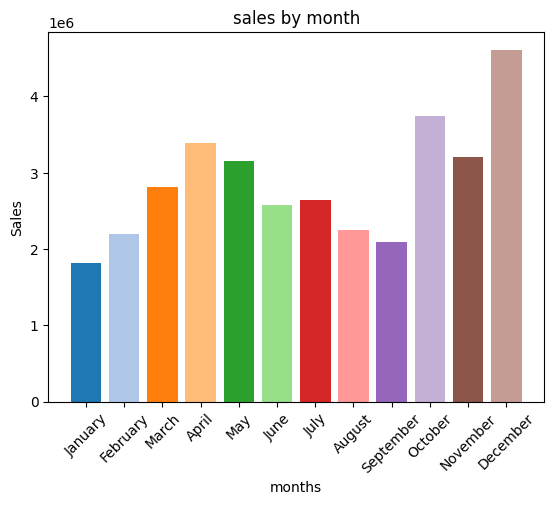

In [88]:
#lets visualize them
import matplotlib.pyplot as plt
monthly=all_data.groupby('Month')['sales'].sum()
order=list(calendar.month_name)[1:]
monthly=monthly.reindex(order)
colors=plt.cm.tab20(range(len(order)))
plt.bar(monthly.index,monthly.values,color=colors)
plt.ylabel('Sales')
plt.xlabel('months')
plt.title("sales by month")
plt.xticks(rotation=45)
plt.savefig('monthlysalebar.png',dpi=300)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'Atlanta,GA'),
  Text(1, 0, 'Austin,TX'),
  Text(2, 0, 'Boston,MA'),
  Text(3, 0, 'Dallas,TX'),
  Text(4, 0, 'Los Angeles,CA'),
  Text(5, 0, 'New York City,NY'),
  Text(6, 0, 'Portland,ME'),
  Text(7, 0, 'Portland,OR'),
  Text(8, 0, 'San Francisco,CA'),
  Text(9, 0, 'Seattle,WA')])

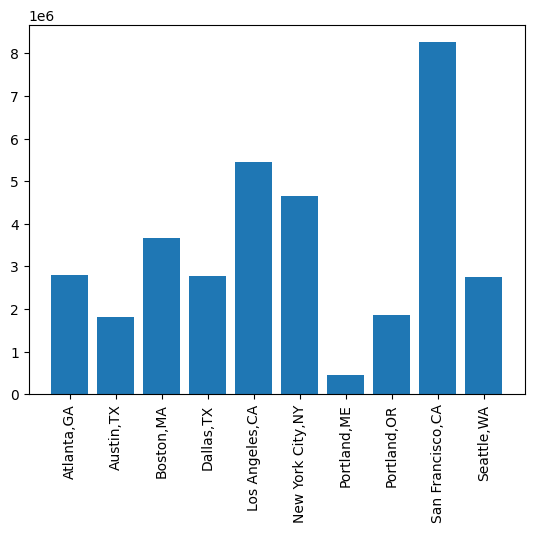

In [93]:
city_sales=all_data.groupby('city&state')['sales'].sum()
plt.bar(city_sales.index,city_sales.values)
plt.xticks(rotation='vertical')
plt.show()

#Question 3: What time should we display advertisements to maximize likelihood of customer's buying product?


In [117]:
#first lets check if the data is uniformly distributed or not to find out if hr has really effect on sales
# null hypothesis= there are no difference among sales per hr
# alternative hypothesis= there exist significant differences

all_data['hour']=pd.to_datetime(all_data['Order Date']).dt.hour
from scipy.stats import chisquare
hourly=all_data.groupby('hour').size()
chi2,p=chisquare(hourly)
print(f'chisq:{chi2:.2f} & p:{p:}')
if p<.05:
  print(f'there are significant difference & highest hr is {hourly.idxmax()}')
else:
  print("no difference in sales based on hour")

chisq:58878.50 & p:0.0
there are significant difference & highest hr is 19


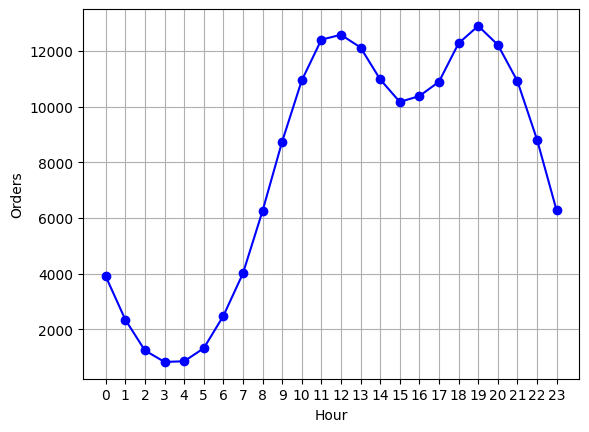

In [118]:
hourly = all_data.groupby("hour").size()

plt.plot(hourly.index, hourly.values, color="blue", marker="o")
plt.xticks(range(0, 24))   # force all 24 hours
plt.xlabel("Hour")
plt.ylabel("Orders")
plt.grid()
plt.show()

#Does order quantity depend on price? (price sensitivity)

In [121]:
from numpy._core.numeric import correlate
#H0: β1 = 0   (price has no effect on quantity)
#H1: β1 != 0   (price affects quantity)

from scipy.stats import pearsonr, spearmanr #as out data may not be linear we will use both
spear,pval_spear=spearmanr(all_data['Price Each'],all_data['Quantity Ordered'])
print(f'spearman rank correlation is: {spear: .3f} and p value is {pval_spear:.4g}')

pearson, p_corr = pearsonr(all_data["Price Each"], all_data["Quantity Ordered"])
print(f"Pearson r = {pearson:.3f}, p = {p_corr:.4g}")

spearman rank correlation is: -0.344 and p value is 0
Pearson r = -0.148, p = 0


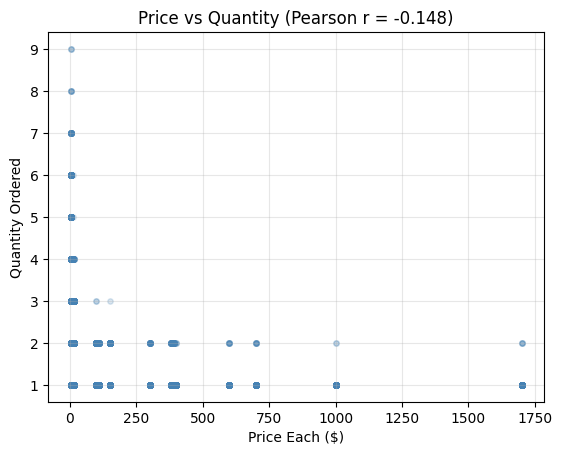

In [123]:
plt.scatter(all_data["Price Each"], all_data["Quantity Ordered"],
            alpha=0.2, s=15, color="steelblue")
plt.xlabel("Price Each ($)")
plt.ylabel("Quantity Ordered")
plt.title("Price vs Quantity (Pearson r = -0.148)")
plt.grid(alpha=0.3)
plt.show()

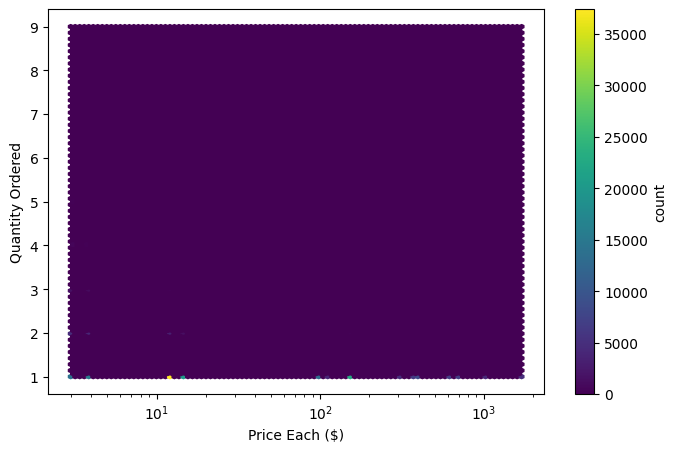

In [130]:
#relation is not linear so we can use heat map to find out more info
plt.figure(figsize=(8,5))
plt.hexbin(all_data["Price Each"], all_data["Quantity Ordered"],xscale="log")
plt.colorbar(label='count')
plt.xlabel("Price Each ($)")
plt.ylabel("Quantity Ordered")
plt.show()

#Are sales significantly different across cities?

In [139]:
#H0: mean sales per order is equal across all cities
#H1: at least one city differs

from scipy.stats import f_oneway
groups=[g['sales'] for _,g in all_data.groupby('city&state')]
f,p=f_oneway(*groups)
print(f"F = {f:.2f}, p = {p:.4g}")

F = 0.43, p = 0.9184


What product sold the most? Why do you think it sold the most?

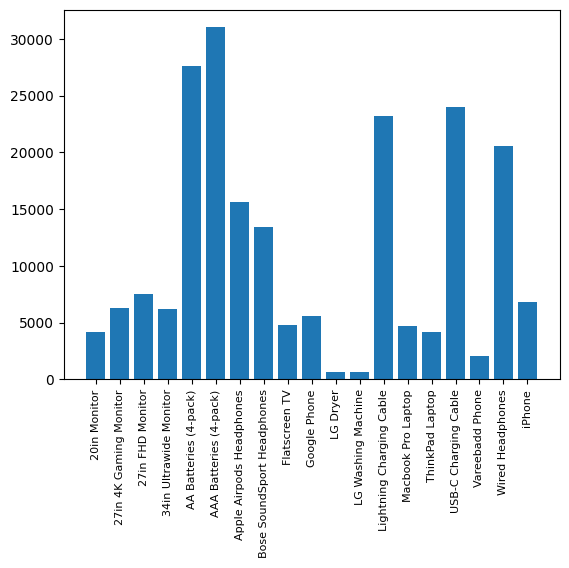

In [140]:
quantity_ordered = all_data.groupby("Product")["Quantity Ordered"].sum()

plt.bar(quantity_ordered.index, quantity_ordered.values)
plt.xticks(quantity_ordered.index, rotation="vertical", size=8)
plt.show()